##Problem Statement

The objective of this project is to build a Random forest model based on the autombile data given to you.
You have been given cars data with different combination of saftey features,capacity etc. your model shouldbe able to predict weather the car is expectable,unacceptable,good or very good.

  The columns in the dataset are 'buying','Maint','doors','persons','lug_boot','saftey' and the final output as 'class'

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix, precision_score, recall_score, f1_score

In [ ]:
df = pd.read_csv('/content/carevaluation.csv', names= ['buying','maint','doors','persons','lug_boot','saftey','class'])

In [ ]:
df.head()

,buying,maint,doors,persons,lug_boot,saftey,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


In [ ]:
df.shape

(1728, 7)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1728 non-null   object
 1   maint     1728 non-null   object
 2   doors     1728 non-null   object
 3   persons   1728 non-null   object
 4   lug_boot  1728 non-null   object
 5   saftey    1728 non-null   object
 6   class     1728 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


In [ ]:
df.describe().T

,count,unique,top,freq
buying,1728,4,vhigh,432
maint,1728,4,vhigh,432
doors,1728,4,2,432
persons,1728,3,2,576
lug_boot,1728,3,small,576
saftey,1728,3,low,576
class,1728,4,unacc,1210


In [ ]:
#df.columns[df.nunique() == len(df)]
unique_columns = df.columns[df.nunique() == len(df)].tolist()
print(unique_columns)

[]


In [ ]:
df.isnull().sum()

,0
buying,0
maint,0
doors,0
persons,0
lug_boot,0
saftey,0
class,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
for col in df.columns:
  print(col,':',df[col].value_counts())

buying : buying
vhigh    432
high     432
med      432
low      432
Name: count, dtype: int64
maint : maint
vhigh    432
high     432
med      432
low      432
Name: count, dtype: int64
doors : doors
2        432
3        432
4        432
5more    432
Name: count, dtype: int64
persons : persons
2       576
4       576
more    576
Name: count, dtype: int64
lug_boot : lug_boot
small    576
med      576
big      576
Name: count, dtype: int64
saftey : saftey
low     576
med     576
high    576
Name: count, dtype: int64
class : class
unacc    1210
acc       384
good       69
vgood      65
Name: count, dtype: int64


In [ ]:
encoders={}

In [ ]:
for col in df.columns:
  le =LabelEncoder()
  df[col] = le.fit_transform(df[col])
  encoders[col] = le

In [ ]:
encoders

{'buying': LabelEncoder(),
 'maint': LabelEncoder(),
 'doors': LabelEncoder(),
 'persons': LabelEncoder(),
 'lug_boot': LabelEncoder(),
 'saftey': LabelEncoder(),
 'class': LabelEncoder()}

In [ ]:
#display encoding mappings
for col,encoder in encoders.items():
  mappings= dict(zip(encoder.classes_,encoder.transform(encoder.classes_)))
  print(f"{col} mapping:")
  print(mappings)


buying mapping:
{'high': np.int64(0), 'low': np.int64(1), 'med': np.int64(2), 'vhigh': np.int64(3)}
maint mapping:
{'high': np.int64(0), 'low': np.int64(1), 'med': np.int64(2), 'vhigh': np.int64(3)}
doors mapping:
{'2': np.int64(0), '3': np.int64(1), '4': np.int64(2), '5more': np.int64(3)}
persons mapping:
{'2': np.int64(0), '4': np.int64(1), 'more': np.int64(2)}
lug_boot mapping:
{'big': np.int64(0), 'med': np.int64(1), 'small': np.int64(2)}
saftey mapping:
{'high': np.int64(0), 'low': np.int64(1), 'med': np.int64(2)}
class mapping:
{'acc': np.int64(0), 'good': np.int64(1), 'unacc': np.int64(2), 'vgood': np.int64(3)}


<Axes: xlabel='class'>

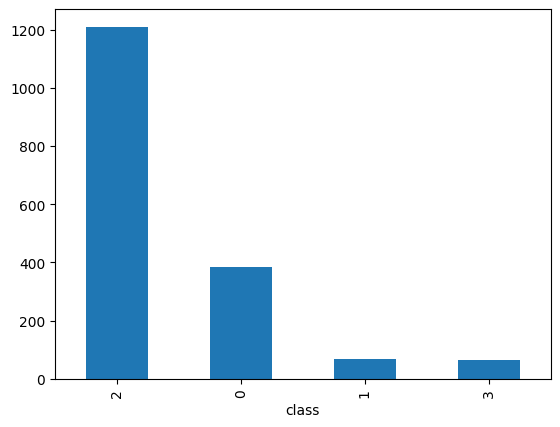

In [ ]:
#count class for plot
df['class'].value_counts().plot(kind='bar')


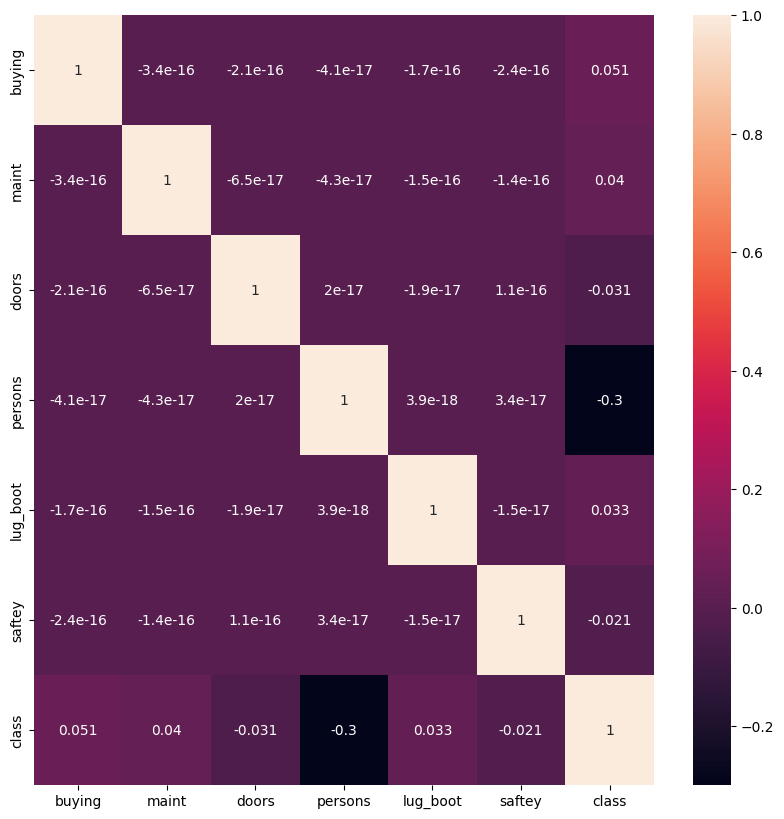

In [ ]:
#Correlation matrix
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(),annot=True)
plt.show()


ML Model building

In [ ]:
x = df.drop('class',axis=1)
y = df['class']

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2)

In [ ]:
rf= RandomForestClassifier(n_estimators=100)

In [ ]:
rf.fit(x_train,y_train)

RandomForestClassifier()

In [ ]:
y_pred = rf.predict(x_test)

In [ ]:
#Model Evaluation
acc = accuracy_score(y_test,y_pred)
print(f"Accuracy = {acc}")

pre = precision_score(y_test,y_pred, average = 'weighted')
print(f"Precision = {pre}")

rec  = recall_score(y_test,y_pred, average = 'weighted')
print(f"Recall = {rec}")

f1score = f1_score(y_test,y_pred, average = 'weighted')
print(f"F1-Score = {f1score}")

print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy = 0.9710982658959537
Precision = 0.9711670795485826
Recall = 0.9710982658959537
F1-Score = 0.9710376025859903

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.94      0.94        64
           1       0.86      0.80      0.83        15
           2       0.99      0.99      0.99       256
           3       0.83      0.91      0.87        11

    accuracy                           0.97       346
   macro avg       0.91      0.91      0.91       346
weighted avg       0.97      0.97      0.97       346


Confusion Matrix:
 [[ 60   2   2   0]
 [  1  12   0   2]
 [  2   0 254   0]
 [  1   0   0  10]]


Text(0, 0.5, 'Features')

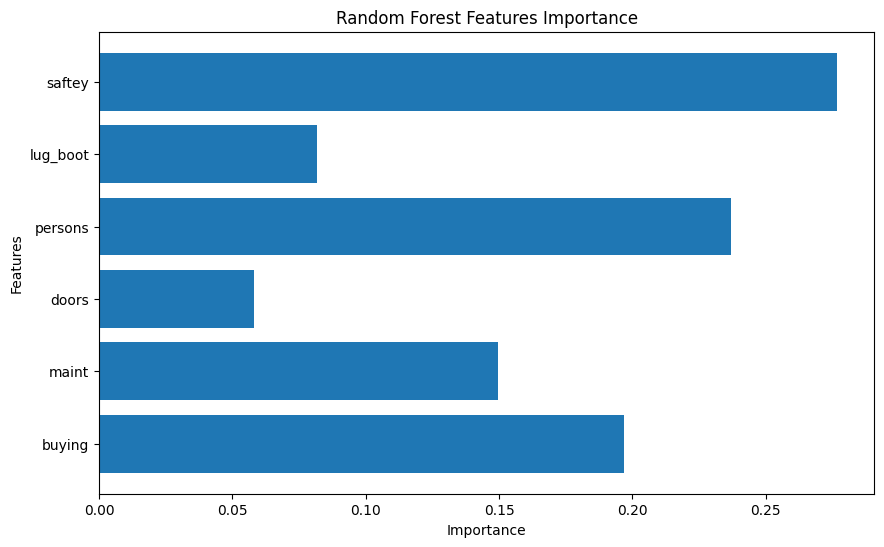

In [ ]:
#Feature Importance
feature_importance = rf.feature_importances_
features_names = x.columns
plt.figure(figsize=(10,6))
plt.barh(features_names, feature_importance)
plt.title("Random Forest Features Importance")
plt.xlabel("Importance")
plt.ylabel("Features")

In [ ]:
#Hyper parameter tuning
from sklearn.model_selection import GridSearchCV

In [ ]:
param_grid={
  'n_estimators':[50,100,200],
  'max_depth':[None,10,20,30],
  'min_samples_split':[2,5,10],
  'min_samples_leaf':[1,2,4]

}

In [ ]:
grid = GridSearchCV(estimator=rf,param_grid=param_grid,cv=5,scoring='accuracy')

In [ ]:
grid.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'max_depth': [None, 10, 20, 30],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             scoring='accuracy')

In [ ]:
print("Best Parameters:",grid.best_params_)
print("Best Score:",grid.best_score_)

Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best Score: 0.9688719719562601


In [ ]:
best_rf=grid.best_estimator_

In [ ]:
y_pred = best_rf.predict(x_test)

In [ ]:
#model evaluation based on hyper parameter
acc = accuracy_score(y_test,y_pred)
print(f"Accuracy = {acc}")
rec  = recall_score(y_test,y_pred, average = 'weighted')
print(f"Recall = {rec}")
pre = precision_score(y_test,y_pred, average = 'weighted')
print(f"Precision = {pre}")
f1score = f1_score(y_test,y_pred, average = 'weighted')
print(f"F1-Score = {f1score}")

confusion_matrix=confusion_matrix(y_test,y_pred)
print("\nConfusion Matrix:\n", confusion_matrix)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy = 0.9682080924855492
Recall = 0.9682080924855492
Precision = 0.9686529525104839
F1-Score = 0.967829031808761

Confusion Matrix:
 [[ 61   1   2   0]
 [  3  11   0   1]
 [  3   0 253   0]
 [  1   0   0  10]]

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.95      0.92        64
           1       0.92      0.73      0.81        15
           2       0.99      0.99      0.99       256
           3       0.91      0.91      0.91        11

    accuracy                           0.97       346
   macro avg       0.93      0.90      0.91       346
weighted avg       0.97      0.97      0.97       346



In [ ]:
#Prediction for new car
new_car ={
    'buying': 'low',
    'maint': 'low',
    'doors': '4',
    'persons': '4',
    'lug_boot': 'big',
    'saftey': 'high'
}


In [ ]:
new_df = pd.DataFrame([new_car])


In [ ]:
new_df

,buying,maint,doors,persons,lug_boot,saftey
0,low,low,4,4,big,high


In [ ]:
#Encoding
for col in new_df.columns:
  le = encoders[col]
  new_df[col] = le.transform(new_df[col])

In [ ]:
new_df

,buying,maint,doors,persons,lug_boot,saftey
0,1,1,2,1,0,0


In [ ]:
prediction = best_rf.predict(new_df)

In [ ]:
#reverse encoding
result = encoders['class'].inverse_transform(prediction)
print(result)

['vgood']
